# A Neural Network Ground State

1D harmonic oscillator, $\hbar=m=\omega=1$:

$$H = -\tfrac12\frac{d^2}{dx^2} + \tfrac12 x^2,\qquad E_0=\tfrac12,\qquad \psi_0=\pi^{-1/4}e^{-x^2/2}$$

The idea: let the neural network **be** the wavefunction $\psi(x;\theta)$, use the energy as the
loss function, and run gradient descent. The variational principle $E[\psi]\ge E_0$ is what makes
this legitimate: the minimum of the loss is exactly the ground state.

That is what sets this apart from an ordinary supervised fit. In a supervised fit the loss
measures the distance between the model output and target values $y_i$ that came with the data.
Here **there is no target and no data** — the loss is built entirely from $\psi$ itself and the
Hamiltonian, so the information about the right answer enters through $H$ instead of through
labels. Everything else carries over untouched: the same training loop, the same
backpropagation, the same optimizer.

Pure numpy throughout. Every gradient is derived by hand and checked against finite differences
before it is used.

## 1. Grid and quadrature weights

The wavefunction lives on a uniform grid over $[-L,L]$. Every integral is written as a weighted
inner product $\int f\,dx \approx w\cdot f$, so the weights appear explicitly in the gradients
later and are harder to get wrong.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

L, N = 8.0, 1601
x = np.linspace(-L, L, N)
dx = x[1] - x[0]
w = np.full(N, dx); w[0] = w[-1] = dx / 2          # trapezoid weights: ∫f dx ≈ w @ f

V_pot = 0.5 * x**2                                  # potential; change this line to change problem

print(f"grid [{-L}, {L}], N={N}, dx={dx:.5f}")

grid [-8.0, 8.0], N=1601, dx=0.01000


## 2. Variation method

$$L[\psi] \;=\; \frac{\displaystyle\int\Big[\tfrac12|\psi'|^2 + V(x)|\psi|^2\Big]dx}{\displaystyle\int|\psi|^2dx}$$

Two notes:

- The kinetic term is written as $\tfrac12\int|\psi'|^2$ rather than $-\tfrac12\int\psi\psi''$.
  They differ by an integration by parts, and the boundary term $[\psi\psi']_{-L}^{L}$ vanishes
  because $\psi\to0$ for a bound state. The payoff: only one derivative is needed, and this form
  is manifestly non-negative, so discretization error is unlikely to fake an $E<E_0$.
- The denominator is not optional. The numerator is homogeneous of degree 2 in $\psi$, so
  minimizing it alone lets the network collapse to $\psi\to0$. Written as a ratio (the Rayleigh
  quotient) the loss is scale-invariant, which closes that shortcut.

In [12]:
def energy(psi, dpsi):
    """Return (E, <T>, <V>), each already divided by the norm."""
    nrm = w @ psi**2
    T = 0.5 * (w @ dpsi**2)
    V = w @ (V_pot * psi**2)
    return (T + V) / nrm, T / nrm, V / nrm

### CHECK 0 — validate the functional before introducing the network

Substitute the analytic solution $\psi_0=\pi^{-1/4}e^{-x^2/2}$ directly. It should give $E=1/2$,
and by the virial theorem $\langle T\rangle=\langle V\rangle=1/4$.

This has to pass first. It isolates the energy functional, the grid and the quadrature from the
network and its optimization, so that a wrong $E$ further down can only have come from the
network side.

In [13]:
psi_ex = np.pi**-0.25 * np.exp(-x**2 / 2)
dpsi_ex = -x * psi_ex

E_ex, T_ex, V_ex = energy(psi_ex, dpsi_ex)
print(f"E     = {E_ex:.12f}   (expect 0.5)")
print(f"<T>   = {T_ex:.12f}   (expect 0.25)")
print(f"<V>   = {V_ex:.12f}   (expect 0.25)")
print(f"norm  = {w @ psi_ex**2:.12f}   (expect 1.0)")

assert abs(E_ex - 0.5) < 1e-9 and abs(T_ex - V_ex) < 1e-9

E     = 0.500000000000   (expect 0.5)
<T>   = 0.250000000000   (expect 0.25)
<V>   = 0.250000000000   (expect 0.25)
norm  = 1.000000000000   (expect 1.0)


## 3. Ansatz

$$\psi(x;\theta) \;=\; \underbrace{\sum_{j=1}^{M} v_j\tanh(a_jx+b_j)}_{f(x)}\;\cdot\;\underbrace{e^{-\alpha x^2}}_{\text{envelope}},\qquad \alpha=e^{s}$$

The Gaussian envelope is needed because **a bare tanh network tends to a constant as
$|x|\to\infty$**, which is not normalizable and behaves badly near the grid edges. The envelope
hard-codes the asymptotic analysis — step one of the analytic solution — into the ansatz, the
same role the envelopes play in FermiNet.

$\alpha$ is a **learnable** parameter rather than a hard-wired $1/2$; hard-wiring it would hand
the network the answer. The parametrization $\alpha=e^s$ keeps $\alpha>0$, since a negative
$\alpha$ would make the wavefunction blow up. The initial value is $s=0$, i.e. $\alpha=1$.

The derivative is analytic as well:

$$\psi' = \big[f'(x) - 2\alpha x f(x)\big]e^{-\alpha x^2},\qquad f'(x)=\sum_j v_ja_j\big(1-\tanh^2(a_jx+b_j)\big)$$

In [15]:
def unpack(th, M):
    return th[:M], th[M:2*M], th[2*M:3*M], th[3*M]      # a, b, v, s

def forward(th, M):
    a, b, v, s = unpack(th, M)
    alpha = np.exp(s)
    h = np.tanh(a[:, None] * x[None, :] + b[:, None])   # (M, N)
    d = 1.0 - h**2
    f  = v @ h                                          # network output
    df = (v * a) @ d                                    # df/dx
    g = np.exp(-alpha * x**2)                           # envelope
    psi  = f * g
    dpsi = (df - 2*alpha*x*f) * g
    return psi, dpsi, dict(a=a, v=v, alpha=alpha, h=h, d=d, g=g)

def loss(th, M):
    psi, dpsi, _ = forward(th, M)
    return energy(psi, dpsi)[0]

def init(M, seed=0):
    rng = np.random.default_rng(seed)
    return np.concatenate([rng.normal(0, 1, M),             # a: slopes
                           rng.uniform(-3, 3, M),           # b: spread kinks over the domain
                           rng.normal(0, 1/np.sqrt(M), M),  # v: output weights
                           [0.0]])                          # s: alpha = 1

## 4. Backpropagation

Ordinary backpropagation: seed the derivative at the loss, then push it back through each layer
by the chain rule. Two features are specific to this problem — the loss is an energy functional
rather than a distance to target values, and $\theta$ reaches the loss through **two channels**
($\psi$ and $\psi'$), so the backward pass starts from two seeds instead of one.

Discretized, $L=\dfrac{T+V}{\mathcal N}$ with $T=\tfrac12\sum_i w_i\psi_i'^2$,
$V=\sum_i w_iV_i\psi_i^2$, $\mathcal N=\sum_i w_i\psi_i^2$.

**The two seeds** (differentiating the quotient — note that $E$ itself shows up):

$$P_i\equiv\frac{\partial L}{\partial\psi_i}=\frac{2w_i}{\mathcal N}\big(V_i\psi_i-E\psi_i\big),
\qquad Q_i\equiv\frac{\partial L}{\partial\psi'_i}=\frac{w_i\psi'_i}{\mathcal N}$$

**Through the envelope** ($\psi=fg$, $\psi'=(f'-2\alpha xf)g$):

$$F_i\equiv\frac{\partial L}{\partial f_i}=g_i\big(P_i-2\alpha x_iQ_i\big),\qquad
G_i\equiv\frac{\partial L}{\partial f'_i}=g_iQ_i$$

$$\frac{\partial L}{\partial\alpha}=-\sum_i x_i^2\psi_iP_i-\sum_i x_i^2\psi'_iQ_i-2\sum_i x_i\psi_iQ_i,
\qquad \frac{\partial L}{\partial s}=\alpha\frac{\partial L}{\partial\alpha}$$

**Through the tanh layer** ($h_{ji}=\tanh(a_jx_i+b_j)$, $d_{ji}=1-h_{ji}^2$):

$$\frac{\partial L}{\partial v_j}=\sum_iF_ih_{ji}\;+\;a_j\sum_iG_id_{ji}$$

$$\frac{\partial L}{\partial a_j}=v_j\sum_iF_id_{ji}x_i\;+\;v_j\sum_iG_id_{ji}\;-\;2v_ja_j\sum_iG_ih_{ji}d_{ji}x_i$$

$$\frac{\partial L}{\partial b_j}=v_j\sum_iF_id_{ji}\;-\;2v_ja_j\sum_iG_ih_{ji}d_{ji}$$

In [16]:
def grads(th, M):
    psi, dpsi, c = forward(th, M)
    a, v, alpha, h, d, g = c['a'], c['v'], c['alpha'], c['h'], c['d'], c['g']

    nrm = w @ psi**2
    E = (0.5 * (w @ dpsi**2) + w @ (V_pot * psi**2)) / nrm

    P = 2.0 * w * (V_pot * psi - E * psi) / nrm      # dL/dpsi
    Q = w * dpsi / nrm                               # dL/dpsi'

    # --- through the envelope ---
    F = g * (P - 2*alpha*x*Q)                        # dL/df
    G = g * Q                                        # dL/df'
    dL_dalpha = -(x**2) @ (psi*P) - (x**2) @ (dpsi*Q) - 2.0 * (x @ (psi*Q))
    gs = alpha * dL_dalpha                           # alpha = exp(s)

    # --- through the tanh layer ---
    gv = (h @ F) + a * (d @ G)
    ga = v * (d @ (F*x)) + v * (d @ G) - 2*v*a * ((h*d) @ (G*x))
    gb = v * (d @ F)                                - 2*v*a * ((h*d) @ G)

    return E, np.concatenate([ga, gb, gv, [gs]])

### CHECK 1 — finite-difference gradient check

To confirm that the hand-derived gradient is correct, it is tested numerically against a central
difference: each parameter is perturbed one at a time and the result is compared with the
analytic expression.

$$\frac{\partial L}{\partial\theta_k}\approx\frac{L(\theta+\epsilon e_k)-L(\theta-\epsilon e_k)}{2\epsilon}$$

The test runs on a small network ($M=12$); the relative error should land around $10^{-9}$.
Nothing downstream is meaningful until this passes, so the cell asserts on the result.

In [17]:
M_test = 12
th_test = init(M_test, seed=1)

_, g_analytic = grads(th_test, M_test)
eps = 1e-6
g_fd = np.array([(loss(th_test + eps*e, M_test) - loss(th_test - eps*e, M_test)) / (2*eps)
                 for e in np.eye(len(th_test))])

err = np.abs(g_analytic - g_fd).max()
rel = err / np.abs(g_fd).max()
print(f"max|analytic - finite diff| = {err:.3e}")
print(f"relative error              = {rel:.3e}")

assert rel < 1e-6, "gradient derivation is wrong -- do not go further"


max|analytic - finite diff| = 1.431e-10
relative error              = 4.012e-10


## 5. Training

Each step computes the gradient of the energy with respect to every parameter, takes one step
downhill, and repeats — 6000 times in all. `hist` records the energy at every step, which
CHECK 2 then uses to confirm the descent never crosses below $E_0$.

The optimizer is **Adam** (Kingma & Ba, 2015), written out in five lines. It scales each
parameter's step by a running average of that parameter's own gradient magnitude, which matters
here because the gradients are very unequal — at initialization the RMS gradient is $\approx2.7$
for the output weights $v$ against $\approx0.025$ for the envelope parameter $s$. `lr` is the
only constant worth tuning; the rest are the paper's defaults.

**Nothing in this loop is specific to quantum mechanics.** It is the same
compute-gradient $\to$ update $\to$ repeat structure as any curve fit. The single difference is
that `grads()` returns the gradient of the *energy* rather than the gradient of a squared error
against target values.

In [18]:
M = 32
th = init(M, seed=0)

lr, b1, b2 = 3e-3, 0.9, 0.999
m_, v_ = np.zeros_like(th), np.zeros_like(th)
hist = []

for t in range(1, 6001):
    E, g = grads(th, M)
    m_ = b1*m_ + (1-b1)*g
    v_ = b2*v_ + (1-b2)*g**2
    th -= lr * (m_/(1-b1**t)) / (np.sqrt(v_/(1-b2**t)) + 1e-8)
    hist.append(E)
    if t == 1 or t % 1000 == 0:
        print(f"step {t:5d}   E = {E:.10f}")

hist = np.array(hist)

step     1   E = 0.9043675347
step  1000   E = 0.5001175031
step  2000   E = 0.5000198636
step  3000   E = 0.5000060505
step  4000   E = 0.5000024107
step  5000   E = 0.5000012258
step  6000   E = 0.5000007139


## 6. Checks

Four checks. Two of them — $E\to1/2$ and the overlap with the exact state — are the ones called
for in `Variational_Ground_State.md`; the other two are independent cross-checks.

Note that the target value of the loss is **$1/2$, not $0$**. A loss still sliding toward zero
would mean something is broken, not that training is going well.

In [19]:
psi, dpsi, c = forward(th, M)
E, T, V = energy(psi, dpsi)

psi = psi / np.sqrt(w @ psi**2)                    # normalize
if w @ (psi * psi_ex) < 0:                         # overall sign carries no physics
    psi = -psi
overlap = w @ (psi * psi_ex)

print(f"CHECK 2  E = {E:.10f}      E - 1/2 = {E-0.5:+.3e}")
print(f"         lowest E during training = {hist.min():.10f}   below 1/2? {bool((hist < 0.5).any())}")
print(f"CHECK 3  overlap = {overlap:.10f}   1 - overlap = {1-overlap:.3e}")
print(f"CHECK 4  virial: <T> = {T:.8f}  <V> = {V:.8f}   |<T>-<V>| = {abs(T-V):.3e}")
print(f"CHECK 5  max|psi - psi_exact| = {np.abs(psi - psi_ex).max():.3e}")
print(f"         learned alpha = {c['alpha']:.6f}")

CHECK 2  E = 0.5000007136      E - 1/2 = +7.136e-07
         lowest E during training = 0.5000007139   below 1/2? False
CHECK 3  overlap = 0.9999999578   1 - overlap = 4.225e-08
CHECK 4  virial: <T> = 0.25000485  <V> = 0.24999586   |<T>-<V>| = 8.995e-06
CHECK 5  max|psi - psi_exact| = 2.639e-04
         learned alpha = 0.536161


**What each check is actually testing:**

| | Content | What it catches |
|---|---|---|
| CHECK 2 | $E\to1/2$, and **never dips below** $1/2$ | The one-sided check from the variational principle. Dipping below means a bug — usually a missing normalization or a mishandled kinetic term |
| CHECK 3 | $\lvert\langle\psi\vert\psi_{\rm exact}\rangle\rvert\to1$ | The right energy could be a coincidence; the overlap confirms the right **function** |
| CHECK 4 | virial: $\langle T\rangle=\langle V\rangle$ | A physical constraint independent of the first two; an error in either $T$ or $V$ inside `energy()` shows up here |
| CHECK 5 | Largest pointwise deviation | Stricter than the overlap, which can average a local error away |

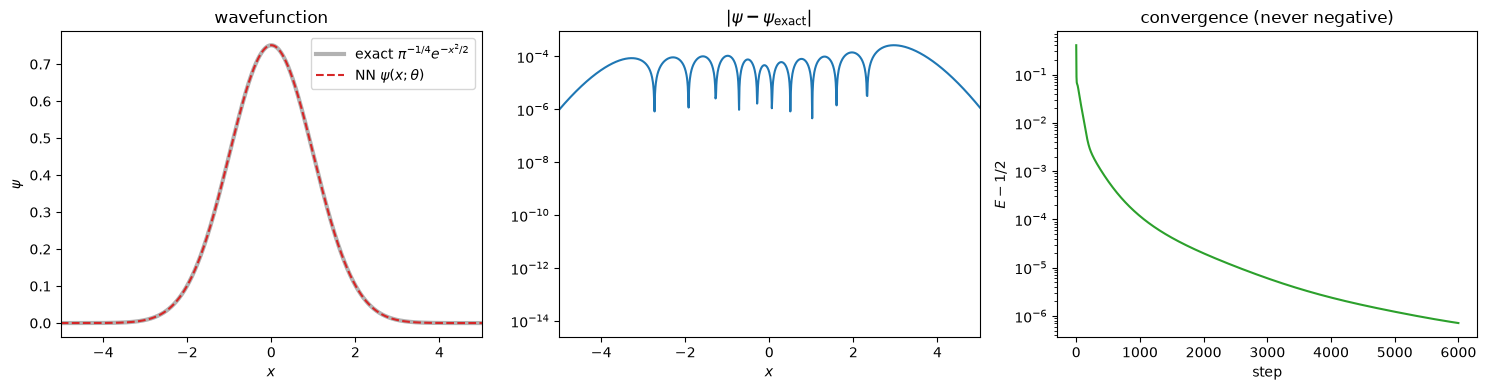

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(x, psi_ex, 'k-', lw=3, alpha=.3, label=r'exact $\pi^{-1/4}e^{-x^2/2}$')
ax[0].plot(x, psi, 'C3--', lw=1.5, label=r'NN $\psi(x;\theta)$')
ax[0].set_xlim(-5, 5); ax[0].set_xlabel('$x$'); ax[0].set_ylabel(r'$\psi$')
ax[0].legend(); ax[0].set_title('wavefunction')

ax[1].semilogy(x, np.abs(psi - psi_ex) + 1e-18, 'C0')
ax[1].set_xlim(-5, 5); ax[1].set_xlabel('$x$')
ax[1].set_title(r'$|\psi - \psi_{\rm exact}|$')

ax[2].semilogy(hist - 0.5, 'C2')
ax[2].set_xlabel('step'); ax[2].set_ylabel('$E - 1/2$')
ax[2].set_title('convergence (never negative)')

plt.tight_layout(); plt.show()